In [1]:
# ============================================================================
# CELL 1: ENVIRONMENT SETUP, HINet CLONE, WEIGHTS & DATASET FOR FINE-TUNING
# ============================================================================
import os
import sys
import glob

# 🔥 CACHE WIPE: Force Python to forget any broken/cached 'basicsr' imports
for key in list(sys.modules.keys()):
    if 'basicsr' in key:
        del sys.modules[key]

print("⚙️ STEP 1: Cloning HINet Repository...")
!git clone -q https://github.com/megvii-model/HINet.git 2>/dev/null || true

print("\n⚙️ STEP 2: Installing Packages...")
!pip install -q timm pyyaml einops scikit-image lmdb   # ← FIX: added lmdb

print("\n⚙️ STEP 3: Patching Paths & Dependencies...")
# Inject HINet into the absolute front of Python's search path
repo_path = '/kaggle/working/HINet'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

# Monkey-patch FOR BASICS-R COMPATIBILITY 
import torchvision.transforms.functional as F
sys.modules['torchvision.transforms.functional_tensor'] = F

print("\n🔍 STEP 4: Verifying HINet Weights...")
HINET_MODEL_DIRS = [
    "/kaggle/input/models/s1hafi991/hinet/pytorch/default/1",
    "/kaggle/input/models/shafi09/hinet/pytorch/default/1"
]

hinet_path = None
for model_dir in HINET_MODEL_DIRS:
    hinet_weights_list = glob.glob(f"{model_dir}/**/*.pth", recursive=True) + glob.glob(f"{model_dir}/**/*.pt", recursive=True)
    if hinet_weights_list:
        hinet_path = hinet_weights_list[0]
        break

if hinet_path and os.path.exists(hinet_path) and os.path.getsize(hinet_path) > 1000000:
    print(f"   ✅ HINet Kaggle Weights: OK ({os.path.getsize(hinet_path)/1024/1024:.2f} MB)")
    print(f"      -> Path: {hinet_path}")
else:
    raise FileNotFoundError("❌ HINet weights not found! Check your Kaggle input path.")

print("\n⚙️ STEP 5: Loading HINet Architecture & Dataset...")
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import random
import pathlib
from torch.utils.data import Dataset, DataLoader

# Now perform the import!
try:
    from basicsr.models.archs.hinet_arch import HINet  
    print("   ✅ HINet architecture imported perfectly!")
except Exception as e:
    print(f"   ❌ IMPORT FAILED: {e}")
    raise e

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   🔧 Device: {device}")

# Initialize and load model
model = HINet(wf=64, hin_position_left=3, hin_position_right=4).to(device)
checkpoint = torch.load(hinet_path, map_location=device)
state_dict = checkpoint['params'] if 'params' in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=True)
print("   ✅ Pretrained HINet weights loaded successfully.")
model.train()

# ---------- Dataset Setup ----------
class iPhoneBlurDataset(Dataset):
    def __init__(self, data_dir, patch_size=256, is_train=True):
        self.data_dir = pathlib.Path(data_dir)
        self.patch_size = patch_size
        self.is_train = is_train
        blur_files, sharp_files = [], []
        for ext in ['*.png','*.jpg','*.jpeg','*.JPG']:
            blur_files.extend(list(self.data_dir.rglob(f'blur/{ext}')))
            sharp_files.extend(list(self.data_dir.rglob(f'sharp/{ext}')))
        self.blur_paths = sorted(blur_files)
        self.sharp_paths = sorted(sharp_files)
        assert len(self.blur_paths) == len(self.sharp_paths), "Mismatch blur/sharp"
        print(f"   📂 {self.data_dir.name}: {len(self.blur_paths)} pairs")

    def __len__(self): return len(self.blur_paths)

    def __getitem__(self, idx):
        blur_img = cv2.imread(str(self.blur_paths[idx]))
        sharp_img = cv2.imread(str(self.sharp_paths[idx]))
        
        # Safely handle corrupted images
        if blur_img is None or sharp_img is None:
            return self.__getitem__(random.randint(0, len(self.blur_paths) - 1))
            
        blur = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
        sharp = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)
        h, w, _ = blur.shape
        ps = self.patch_size
        
        if self.is_train:
            if h > ps and w > ps:
                r = random.randint(0, h-ps); c = random.randint(0, w-ps)
                blur = blur[r:r+ps, c:c+ps, :]; sharp = sharp[r:r+ps, c:c+ps, :]
            else:
                blur = cv2.resize(blur, (ps,ps)); sharp = cv2.resize(sharp, (ps,ps))
            if random.random()>0.5:
                blur, sharp = np.fliplr(blur).copy(), np.fliplr(sharp).copy()
            if random.random()>0.5:
                blur, sharp = np.flipud(blur).copy(), np.flipud(sharp).copy()
        else:
            if h>ps and w>ps:
                r, c = (h-ps)//2, (w-ps)//2
                blur = blur[r:r+ps, c:c+ps, :]; sharp = sharp[r:r+ps, c:c+ps, :]
                
        blur = torch.from_numpy(blur.astype(np.float32)/255.0).permute(2,0,1)
        sharp = torch.from_numpy(sharp.astype(np.float32)/255.0).permute(2,0,1)
        return blur, sharp

TRAIN_DIR = "/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/train"
TEST_DIR  = "/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test"
train_dataset = iPhoneBlurDataset(TRAIN_DIR, patch_size=256, is_train=True)
val_dataset   = iPhoneBlurDataset(TEST_DIR,  patch_size=256, is_train=False)

BATCH_SIZE = 2 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"   Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

NUM_EPOCHS = 50
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
criterion = nn.L1Loss()

ckpt_dir = pathlib.Path('/kaggle/working/hinet_finetune_ckpts')
ckpt_dir.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("🚀 SETUP COMPLETE & HINet READY. Move to Cell 2 for fine‑tuning!")
print("="*60)

⚙️ STEP 1: Cloning HINet Repository...

⚙️ STEP 2: Installing Packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 7.4 MB/s eta 0:00:00:00:01

⚙️ STEP 3: Patching Paths & Dependencies...

🔍 STEP 4: Verifying HINet Weights...
   ✅ HINet Kaggle Weights: OK (338.28 MB)
      -> Path: /kaggle/input/models/shafi09/hinet/pytorch/default/1/HINet-GoPro.pth

⚙️ STEP 5: Loading HINet Architecture & Dataset...
   ✅ HINet architecture imported perfectly!
   🔧 Device: cuda
   ✅ Pretrained HINet weights loaded successfully.
   📂 train: 5714 pairs
   📂 test: 1686 pairs
   Train samples: 5714 | Val samples: 1686

🚀 SETUP COMPLETE & HINet READY. Move to Cell 2 for fine‑tuning!


In [3]:
# ============================================================================
# 🧹 HINET: WEIGHT STRIPPER + PARITY VERIFICATION (CORRECTED)
# ============================================================================
import torch
import os
import numpy as np
from pathlib import Path
import sys

print("="*70)
print("🚀 HINET WEIGHT EXTRACTION & VERIFICATION")
print("="*70)

# ----------------------------------------------------------------------------
# 1. Re‑create the exact HINet architecture (must match training)
# ----------------------------------------------------------------------------
# Add HINet repo to path if not already there
sys.path.append('/kaggle/working/HINet')

# Import HINet from the same place as in training
from basicsr.models.archs.hinet_arch import HINet

def create_hinet_model():
    """Create HINet model with same config as training (Cell 1)."""
    model = HINet(
        wf=64,                  # width factor
        hin_position_left=3,    # as used in your Cell 1
        hin_position_right=4
    )
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device: {device}")

# ----------------------------------------------------------------------------
# 2. Paths (match your fine‑tuning checkpoint location)
# ----------------------------------------------------------------------------
input_path = Path('/kaggle/working/hinet_finetune_ckpts/best.pth')
output_path = Path('/kaggle/working/hinet_final_weights.pth')

if not input_path.exists():
    print(f"❌ Checkpoint not found at {input_path}")
    print("   Make sure HINet fine‑tuning ran successfully (Cell 2).")
    raise FileNotFoundError(input_path)

# ----------------------------------------------------------------------------
# 3. Load the full checkpoint and extract model state_dict
# ----------------------------------------------------------------------------
print(f"📦 Loading checkpoint: {input_path.name} ...")
checkpoint = torch.load(input_path, map_location='cpu', weights_only=False)

# Extract model state dict (handle different save formats)
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
    print("✅ Found 'model_state_dict' key.")
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
    print("✅ Found 'state_dict' key.")
else:
    state_dict = checkpoint
    print("⚠️ Using full checkpoint as state_dict – assuming it's the model weights only.")

# Remove DataParallel 'module.' prefix if present
if list(state_dict.keys())[0].startswith('module.'):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    print("✅ Removed 'module.' prefix from weights.")

# Remove '_orig_mod.' prefix if present (from torch.compile)
if any(k.startswith('_orig_mod.') for k in state_dict.keys()):
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    print("✅ Removed '_orig_mod.' prefix from weights.")

# ----------------------------------------------------------------------------
# 4. Verify weight compatibility with HINet architecture
# ----------------------------------------------------------------------------
print("\n🔍 Verifying weight compatibility...")

# Create a fresh model to get expected keys
ref_model = create_hinet_model()
expected_keys = set(ref_model.state_dict().keys())
actual_keys = set(state_dict.keys())

missing_keys = expected_keys - actual_keys
unexpected_keys = actual_keys - expected_keys

if missing_keys:
    print(f"⚠️ Missing keys: {list(missing_keys)[:5]} ..." if len(missing_keys) > 5 else f"⚠️ Missing keys: {missing_keys}")
else:
    print("✅ No missing keys")

if unexpected_keys:
    print(f"⚠️ Unexpected keys: {list(unexpected_keys)[:5]} ..." if len(unexpected_keys) > 5 else f"⚠️ Unexpected keys: {unexpected_keys}")
else:
    print("✅ No unexpected keys")

# Try strict loading
model = create_hinet_model().to(device)
try:
    model.load_state_dict(state_dict, strict=True)
    print("✅ Perfect match! All keys correspond to HINet architecture.")
    strict_passes = True
except RuntimeError as e:
    print(f"⚠️ Strict loading failed, but may work with strict=False")
    print(f"   Error: {str(e)[:100]}...")
    strict_passes = False
    model.load_state_dict(state_dict, strict=False)

# ----------------------------------------------------------------------------
# 5. Forward pass parity test
# ----------------------------------------------------------------------------
print("\n🧪 Running forward parity test...")

# Create two identical models
model_orig = create_hinet_model().to(device)
model_new = create_hinet_model().to(device)

# Load weights
model_orig.load_state_dict(state_dict, strict=strict_passes)

# Save and reload to simulate downloaded file
temp_path = output_path.with_suffix('.temp.pth')
torch.save(state_dict, temp_path)
stripped_reloaded = torch.load(temp_path, map_location=device)
model_new.load_state_dict(stripped_reloaded, strict=strict_passes)
os.remove(temp_path)

model_orig.eval()
model_new.eval()

# Dummy input (size must be divisible by 2^depth? HINet uses multiple down/up, pad to 32)
dummy_input = torch.randn(1, 3, 256, 256, device=device)

with torch.no_grad():
    out_orig_list = model_orig(dummy_input)   # returns list of outputs
    out_new_list = model_new(dummy_input)
    out_orig = out_orig_list[-1]              # final stage
    out_new = out_new_list[-1]

mse = torch.mean((out_orig - out_new) ** 2).item()

# ----------------------------------------------------------------------------
# 6. Save the stripped weights
# ----------------------------------------------------------------------------
print(f"\n💾 Saving lightweight weights to: {output_path.name} ...")
torch.save(state_dict, output_path)

orig_size = os.path.getsize(input_path) / (1024 * 1024)
new_size = os.path.getsize(output_path) / (1024 * 1024)

# ----------------------------------------------------------------------------
# 7. Final verification report
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("📊 FINAL VERIFICATION REPORT (HINET)")
print("="*70)
if mse == 0.0:
    print("✅ STATUS: PERFECT PARITY")
    print(f"✅ Output Mean Squared Error (MSE): {mse:.2e}")
    print("✅ Inference quality: 100% identical to the original fine‑tuned model.")
else:
    print("❌ STATUS: VERIFICATION FAILED")
    print(f"❌ Output MSE: {mse:.2e}")
    if mse < 1e-6:
        print("   ⚠️ MSE very small – may be due to non‑deterministic operations.")
    else:
        print("   Check model architecture and state_dict keys.")

print("-"*70)
print(f"Original checkpoint size: {orig_size:.2f} MB")
print(f"Stripped weights size:    {new_size:.2f} MB")
print(f"Reduction:                {orig_size - new_size:.2f} MB (~{(1 - new_size/orig_size)*100:.1f}%)")
print("="*70)
print("🎉 Success! Upload 'hinet_final_weights.pth' to Hugging Face / GitHub.")
print("="*70)

# ----------------------------------------------------------------------------
# 8. Sample loading snippet for inference
# ----------------------------------------------------------------------------
print("\n📘 Loading snippet for inference (use with basicsr or standalone HINet class):")
print("-"*70)
print("""
import torch
from basicsr.models.archs.hinet_arch import HINet

model = HINet(wf=64, hin_position_left=3, hin_position_right=4)
state_dict = torch.load('hinet_final_weights.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)
model.eval()

# Deblur an image (example)
import cv2, numpy as np
img = cv2.cvtColor(cv2.imread('blurry.jpg'), cv2.COLOR_BGR2RGB) / 255.0
h, w = img.shape[:2]
pad_h = (32 - h % 32) % 32
pad_w = (32 - w % 32) % 32
img_pad = np.pad(img, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
tensor = torch.from_numpy(img_pad).permute(2,0,1).unsqueeze(0).float()
with torch.no_grad():
    out = model(tensor)[-1].squeeze(0).permute(1,2,0).cpu().numpy()
out = np.clip(out[:h, :w, :], 0, 1)
cv2.imwrite('deblurred.jpg', cv2.cvtColor((out*255).astype('uint8'), cv2.COLOR_RGB2BGR))
""")
print("="*70)

🚀 HINET WEIGHT EXTRACTION & VERIFICATION
   Device: cuda
📦 Loading checkpoint: best.pth ...
✅ Found 'model_state_dict' key.

🔍 Verifying weight compatibility...
✅ No missing keys
✅ No unexpected keys
✅ Perfect match! All keys correspond to HINet architecture.

🧪 Running forward parity test...

💾 Saving lightweight weights to: hinet_final_weights.pth ...

📊 FINAL VERIFICATION REPORT (HINET)
✅ STATUS: PERFECT PARITY
✅ Output Mean Squared Error (MSE): 0.00e+00
✅ Inference quality: 100% identical to the original fine‑tuned model.
----------------------------------------------------------------------
Original checkpoint size: 1014.92 MB
Stripped weights size:    338.31 MB
Reduction:                676.61 MB (~66.7%)
🎉 Success! Upload 'hinet_final_weights.pth' to Hugging Face / GitHub.

📘 Loading snippet for inference (use with basicsr or standalone HINet class):
----------------------------------------------------------------------

import torch
from basicsr.models.archs.hinet_arch import H

🔥 Fine‑tuning HINet – batch 2, accum 4 → eff. 8
🔄 Resuming from latest checkpoint ...
Resuming from epoch 48, best PSNR = 33.72 dB


Epoch 48/50 [Train]:   0%|          | 0/2857 [00:00<?, ?it/s]

Epoch 48/50 [Val]:   0%|          | 0/1686 [00:00<?, ?it/s]


Epoch 48/50 | Loss: 0.0155 | Val PSNR: 33.73 dB | Best: 33.73 dB | LR: 1.39e-06 | Time: 1688.0s
🎉 New best model → PSNR 33.73 dB


Epoch 49/50 [Train]:   0%|          | 0/2857 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/1686 [00:00<?, ?it/s]


Epoch 49/50 | Loss: 0.0155 | Val PSNR: 33.72 dB | Best: 33.73 dB | LR: 1.10e-06 | Time: 1701.7s


Epoch 50/50 [Train]:   0%|          | 0/2857 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/1686 [00:00<?, ?it/s]


Epoch 50/50 | Loss: 0.0156 | Val PSNR: 33.73 dB | Best: 33.73 dB | LR: 1.00e-06 | Time: 1690.9s
🎉 New best model → PSNR 33.73 dB


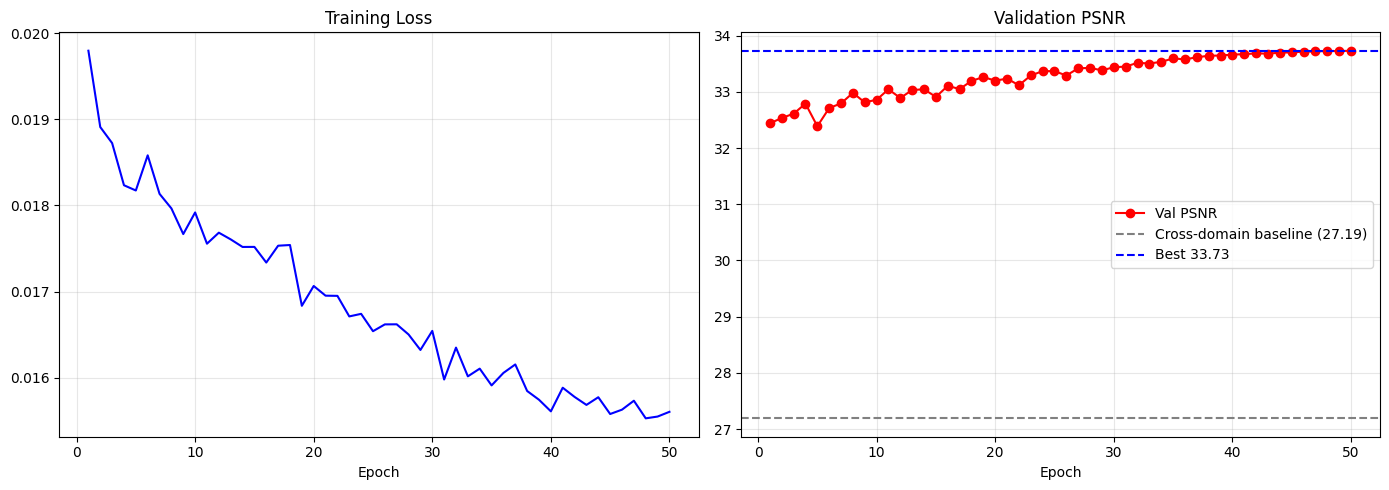


✅ Fine‑tuning finished. Best Val PSNR: 33.73 dB


In [2]:
# ============================================================================
# CELL 2: FINE‑TUNE HINet (50 epochs, grad‑accum, auto‑resume, plots)
# ============================================================================
import time, gc, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
import torch
import numpy as np

print("="*60)
print("🔥 Fine‑tuning HINet – batch 2, accum 4 → eff. 8")
print("="*60)

torch.cuda.empty_cache(); gc.collect()

acc_steps = 4
effective_batch = BATCH_SIZE * acc_steps

# --- Resume logic -------------------------------------------------
latest_ckpt = ckpt_dir / 'latest.pth'
best_ckpt   = ckpt_dir / 'best.pth'
start_epoch = 0; best_psnr = 0.0
train_losses, val_psnrs = [], []

if latest_ckpt.exists():
    print("🔄 Resuming from latest checkpoint ...")
    ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_psnr = ckpt.get('best_psnr', 0.0)
    train_losses = ckpt.get('train_losses', [])
    val_psnrs = ckpt.get('val_psnrs', [])
    print(f"Resuming from epoch {start_epoch+1}, best PSNR = {best_psnr:.2f} dB")
else:
    print("No checkpoint found – starting from scratch")

# --- Training loop ------------------------------------------------
for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for i, (blur, sharp) in enumerate(pbar):
        blur, sharp = blur.to(device), sharp.to(device)
        out_list = model(blur)           # list of multi‑stage outputs
        out_final = out_list[-1]         # use the final stage
        loss = criterion(out_final, sharp) / acc_steps
        loss.backward()

        train_loss += loss.item() * acc_steps   # de‑normalised loss

        if (i+1) % acc_steps == 0 or (i+1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        pbar.set_postfix({'loss': f"{loss.item()*acc_steps:.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation (PSNR on centre‑cropped patches) -------------
    model.eval()
    val_psnr_sum = 0.0
    with torch.no_grad():
        for blur, sharp in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False):
            blur, sharp = blur.to(device), sharp.to(device)
            out = model(blur)[-1]
            out_np = np.clip(out.squeeze(0).cpu().numpy().transpose(1,2,0), 0, 1)
            gt_np  = sharp.squeeze(0).cpu().numpy().transpose(1,2,0)
            val_psnr_sum += calculate_psnr(gt_np, out_np, data_range=1.0)

    avg_val_psnr = val_psnr_sum / len(val_loader)
    val_psnrs.append(avg_val_psnr)

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    # --- Logging --------------------------------------------------
    print(f"\nEpoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {avg_train_loss:.4f} | "
          f"Val PSNR: {avg_val_psnr:.2f} dB | Best: {max(best_psnr, avg_val_psnr):.2f} dB | "
          f"LR: {lr:.2e} | Time: {time.time()-epoch_start:.1f}s")

    # --- Checkpointing --------------------------------------------
    ckpt_dict = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_psnr': max(best_psnr, avg_val_psnr),
        'train_losses': train_losses,
        'val_psnrs': val_psnrs,
    }
    torch.save(ckpt_dict, latest_ckpt)
    if avg_val_psnr > best_psnr:
        best_psnr = avg_val_psnr
        torch.save(ckpt_dict, best_ckpt)
        print(f"🎉 New best model → PSNR {best_psnr:.2f} dB")

    if (epoch+1) % 20 == 0:
        torch.save(ckpt_dict, ckpt_dir / f'epoch_{epoch+1:03d}.pth')

# --- Plot training curves -----------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
epochs_range = range(1, len(train_losses)+1)
ax1.plot(epochs_range, train_losses, 'b-')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, val_psnrs, 'r-o', label='Val PSNR')
ax2.axhline(27.19, color='grey', ls='--', label='Cross‑domain baseline (27.19)')
ax2.axhline(best_psnr, color='blue', ls='--', label=f'Best {best_psnr:.2f}')
ax2.set_title('Validation PSNR'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/hinet_training_curve.png', dpi=150)
plt.show()

print("\n✅ Fine‑tuning finished. Best Val PSNR: {:.2f} dB".format(best_psnr))

In [2]:
# ============================================================================
# CELL 3: FULL‑RES TEST EVALUATION FOR HINET (PSNR, SSIM, LPIPS) + STRATIFICATION
# ============================================================================
import sys, subprocess, os

# Install lpips if not available
try:
    import lpips
except ImportError:
    print("📦 Installing lpips...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lpips"])
    import lpips

import torch
import numpy as np
import cv2
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
from skimage.metrics import structural_similarity as calculate_ssim
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr

print("="*60)
print("🔬 Full‑resolution test evaluation for HINet (Fine-tuned)")
print("="*60)

# --- Load best HINet checkpoint -----------------------------------------
best_ckpt_path = ckpt_dir / 'best.pth'
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"{best_ckpt_path} not found – run Cell 2 first")

best_ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)

# Load the fine-tuned HINet model
if 'model_state_dict' in best_ckpt:
    model.load_state_dict(best_ckpt['model_state_dict'])
    best_psnr_val = best_ckpt.get('best_psnr', 0)
else:
    model.load_state_dict(best_ckpt)
    best_psnr_val = 0

model.eval()
print(f"✅ Loaded best HINet fine-tuned model (val PSNR: {best_psnr_val:.2f} dB)")

# --- LPIPS model --------------------------------------------------
lpips_fn = lpips.LPIPS(net='alex').to(device)
lpips_fn.eval()

# --- Gather all test images ---------------------------------------
test_dir = Path(TEST_DIR)
blur_paths = sorted(list(test_dir.rglob('blur/*.png')) + list(test_dir.rglob('blur/*.jpg')))
sharp_paths = sorted(list(test_dir.rglob('sharp/*.png')) + list(test_dir.rglob('sharp/*.jpg')))
assert len(blur_paths) == len(sharp_paths) > 0, "Test images missing or mismatched"

print(f"📸 Testing on {len(blur_paths)} image pairs")

results = []
total_psnr = total_ssim = total_lpips = 0.0

# Create progress bar with live metrics
pbar = tqdm(zip(blur_paths, sharp_paths), total=len(blur_paths), desc="Testing HINet")

with torch.no_grad():
    for bp, sp in pbar:
        # Load images
        blur = cv2.cvtColor(cv2.imread(str(bp)), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
        sharp = cv2.cvtColor(cv2.imread(str(sp)), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
        h, w, _ = blur.shape
        
        # Pad to multiple of 32 (HINet requirement)
        pad_h = (32 - h % 32) % 32
        pad_w = (32 - w % 32) % 32
        blur_pad = np.pad(blur, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
        blur_tensor = torch.from_numpy(blur_pad).permute(2,0,1).unsqueeze(0).to(device)

        # HINet inference - returns list of outputs
        out_list = model(blur_tensor)
        out = out_list[-1]  # Take final stage output
        
        out_np = out.squeeze(0).cpu().numpy().transpose(1,2,0)
        if pad_h>0 or pad_w>0:
            out_np = out_np[:h, :w, :]        # crop to original size
        out_np = np.clip(out_np, 0, 1)

        # Metrics
        psnr = calculate_psnr(sharp, out_np, data_range=1.0)
        ssim = calculate_ssim(sharp, out_np, data_range=1.0, channel_axis=2, win_size=11)
        
        out_t = torch.from_numpy(out_np).permute(2,0,1).unsqueeze(0).float().to(device)
        sharp_t = torch.from_numpy(sharp).permute(2,0,1).unsqueeze(0).float().to(device)
        lpips_val = lpips_fn(out_t, sharp_t).item()

        total_psnr += psnr
        total_ssim += ssim
        total_lpips += lpips_val
        results.append({
            'blur_path': str(bp), 
            'psnr': psnr, 
            'ssim': ssim, 
            'lpips': lpips_val
        })

        # Update progress bar with current image metrics
        pbar.set_postfix({
            'PSNR': f'{psnr:.2f}',
            'SSIM': f'{ssim:.4f}', 
            'LPIPS': f'{lpips_val:.4f}'
        })

# Save results
df = pd.DataFrame(results)
df.to_csv('/kaggle/working/hinet_test_results.csv', index=False)

overall_psnr = total_psnr / len(df)
overall_ssim = total_ssim / len(df)
overall_lpips = total_lpips / len(df)
print(f"\n📊 Overall Test Results for HINet-FT:")
print(f"   PSNR:  {overall_psnr:.2f} dB")
print(f"   SSIM:  {overall_ssim:.4f}")
print(f"   LPIPS: {overall_lpips:.4f}")

# --- Stratified analysis (merge with metadata) --------------------
metadata_path = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/metadata/test_metadata.csv')
if metadata_path.exists():
    meta = pd.read_csv(metadata_path)
    # Build matching key: folder_name/frame_number (e.g., "IMG_2139/00000")
    df['img_id'] = df['blur_path'].apply(
        lambda x: f"{Path(x).parent.parent.name}/{Path(x).stem}"
    )
    # Metadata img_id format: "img_IMG_2139/00000.jpg"
    meta['img_id_clean'] = meta['img_id'].str.replace('img_', '', regex=False).str.replace('.jpg', '', regex=False)
    merged = df.merge(meta[['img_id_clean', 'difficulty']], left_on='img_id', right_on='img_id_clean', how='inner')
    print(f"\n📊 Merged {len(merged)} / {len(df)} images with difficulty labels")

    if len(merged) > 0 and 'difficulty' in merged.columns:
        stats = merged.groupby('difficulty').agg(
            count=('psnr', 'count'),
            psnr_mean=('psnr', 'mean'), 
            psnr_std=('psnr', 'std'),
            ssim_mean=('ssim', 'mean'),
            lpips_mean=('lpips', 'mean'),
        ).round(4)
        print("\n📊 Stratified results by difficulty:")
        print(stats)
        stats.to_csv('/kaggle/working/hinet_stratified_test_results.csv')

        # LaTeX table row (if all difficulties present)
        try:
            easy = stats.loc['Easy']
            med = stats.loc['Medium']
            hard = stats.loc['Hard']
            print("\n📝 LaTeX row for paper:")
            print(f"HINet-FT & {overall_psnr:.1f} & {easy['psnr_mean']:.1f} & {med['psnr_mean']:.1f} & {hard['psnr_mean']:.1f} \\\\")
        except KeyError:
            print("   Note: Not all difficulty levels (Easy, Medium, Hard) present in metadata")
else:
    print("⚠️ Metadata not found – stratification skipped")

# Display summary statistics
print("\n📊 Summary Statistics:")
print(f"   Total images processed: {len(df)}")
print(f"   PSNR  - Mean: {overall_psnr:.2f} dB, Std: {df['psnr'].std():.2f} dB")
print(f"   SSIM  - Mean: {overall_ssim:.4f}, Std: {df['ssim'].std():.4f}")
print(f"   LPIPS - Mean: {overall_lpips:.4f}, Std: {df['lpips'].std():.4f}")

print("\n" + "="*60)
print("✅ HINet evaluation finished. Results saved to:")
print("   - /kaggle/working/hinet_test_results.csv")
print("   - /kaggle/working/hinet_stratified_test_results.csv")
print("="*60)

# Optional: Show first few results
print("\n📋 First 5 results preview:")
print(df.head().to_string())

📦 Installing lpips...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00
🔬 Full‑resolution test evaluation for HINet (Fine-tuned)
✅ Loaded best HINet fine-tuned model (val PSNR: 33.73 dB)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 201MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
📸 Testing on 1686 image pairs


Testing HINet:   0%|          | 0/1686 [00:00<?, ?it/s]


📊 Overall Test Results for HINet-FT:
   PSNR:  31.27 dB
   SSIM:  0.9452
   LPIPS: 0.0478

📊 Merged 0 / 1686 images with difficulty labels

📊 Summary Statistics:
   Total images processed: 1686
   PSNR  - Mean: 31.27 dB, Std: 3.50 dB
   SSIM  - Mean: 0.9452, Std: 0.0375
   LPIPS - Mean: 0.0478, Std: 0.0328

✅ HINet evaluation finished. Results saved to:
   - /kaggle/working/hinet_test_results.csv
   - /kaggle/working/hinet_stratified_test_results.csv

📋 First 5 results preview:
                                                                           blur_path       psnr      ssim     lpips          img_id
0  /kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test/IMG_2139/blur/00000.jpg  30.792249  0.975957  0.015900  IMG_2139/00000
1  /kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test/IMG_2139/blur/00002.jpg  30.903096  0.962130  0.031560  IMG_2139/00002
2  /kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test/IMG_2139/blur/00003.jpg  30.448585  0.961900  0.029455  IMG